In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
data = pd.read_json("District_Wise_flood_risk_data.json")
data.columns

Index(['ID', 'Vulnerability', 'Hazard', 'Exposure', 'Risk'], dtype='object')

In [74]:
print(data.head())
print(data.shape)

   ID  Vulnerability  Hazard  Exposure   Risk
0   1          0.534    0.08     0.011  0.001
1   2          0.622    0.00     0.000  0.000
2   3          0.421    0.10     0.000  0.000
3   4          0.631    0.14     0.009  0.002
4   5          0.580    0.12     0.031  0.006
(742, 5)


In [76]:
print('To check existance of null value :')
print(data.isnull().sum())

To check existance of null value :
ID               0
Vulnerability    0
Hazard           0
Exposure         0
Risk             0
dtype: int64


In [78]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [80]:
print(data.describe())

               ID  Vulnerability      Hazard    Exposure        Risk
count  742.000000     742.000000  742.000000  742.000000  742.000000
mean   371.500000       0.533487    0.420512    0.067573    0.051379
std    214.341239       0.161385    0.298247    0.131241    0.118936
min      1.000000       0.000000    0.000000    0.000000    0.000000
25%    186.250000       0.424000    0.180000    0.002000    0.001000
50%    371.500000       0.533500    0.380000    0.023000    0.010000
75%    556.750000       0.647750    0.640000    0.067000    0.040000
max    742.000000       1.000000    1.000000    1.000000    1.000000


In [82]:
print('Top 10 :')
print(data.head(10))

Top 10 :
   ID  Vulnerability  Hazard  Exposure   Risk
0   1          0.534    0.08     0.011  0.001
1   2          0.622    0.00     0.000  0.000
2   3          0.421    0.10     0.000  0.000
3   4          0.631    0.14     0.009  0.002
4   5          0.580    0.12     0.031  0.006
5   6          0.371    0.66     0.000  0.000
6   7          0.620    0.06     0.020  0.002
7   8          0.549    0.24     0.000  0.000
8   9          0.422    0.22     0.000  0.000
9  10          0.553    0.54     0.000  0.000


In [84]:
print("Average Vulnerability:", data["Vulnerability"].mean())
print("Average Hazard:", data["Hazard"].mean())
print("Average Exposure:", data["Exposure"].mean())
print("Average Risk:", data["Risk"].mean())

Average Vulnerability: 0.5334865229110511
Average Hazard: 0.4205121293800539
Average Exposure: 0.06757277628032346
Average Risk: 0.051378706199460916


In [86]:
print("Maximum Risk:", data["Risk"].max())
print("Minimum Risk:", data["Risk"].min())

Maximum Risk: 1.0
Minimum Risk: 0.0


In [88]:
high_risk = data.sort_values("Risk", ascending=False)

print(high_risk.head(10))

      ID  Vulnerability  Hazard  Exposure   Risk
564  565          0.647    0.64     0.889  1.000
457  458          0.653    0.64     0.848  0.963
490  491          0.684    0.68     0.753  0.952
581  582          0.643    0.46     0.992  0.797
552  553          0.459    0.64     1.000  0.797
508  509          0.928    0.66     0.434  0.723
578  579          0.680    0.68     0.575  0.722
531  532          0.680    0.54     0.691  0.689
540  541          0.455    0.58     0.875  0.628
567  568          0.803    0.56     0.503  0.615


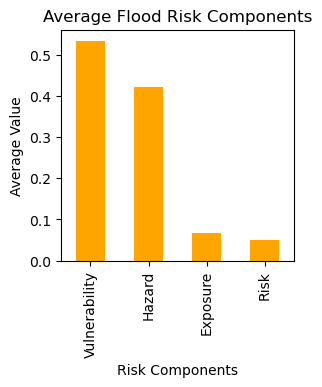

In [90]:

data[["Vulnerability", "Hazard", "Exposure", "Risk"]].mean().plot(kind="bar", color="orange",figsize = (3,3))

plt.title("Average Flood Risk Components")
plt.ylabel("Average Value")
plt.xlabel("Risk Components")
plt.show()

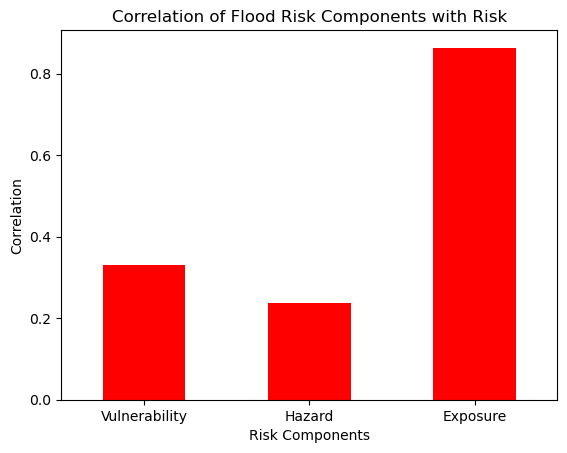

In [92]:
data[[
    "Vulnerability",
    "Hazard",
    "Exposure"
]].corrwith(data["Risk"]).plot(
    kind="bar",
    color="red"
)

plt.title("Correlation of Flood Risk Components with Risk")
plt.ylabel("Correlation")
plt.xlabel("Risk Components")
plt.xticks(rotation=0)
plt.show()

Correlation with Risk:
Risk             1.000000
Exposure         0.863722
Vulnerability    0.330687
Hazard           0.238548
Name: Risk, dtype: float64


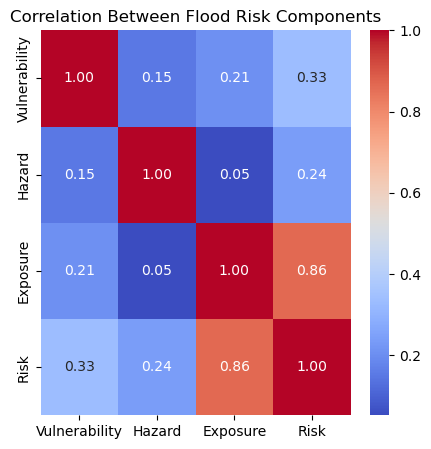

In [94]:
cols = ["Vulnerability", "Hazard", "Exposure", "Risk"]
correlation = data[cols].corr()

print("Correlation with Risk:")
print(correlation["Risk"].sort_values(ascending=False))

plt.figure(figsize=(5,5))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Flood Risk Components")
plt.show()


In [96]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#input
X = data[["Vulnerability", "Hazard", "Exposure"]]
#target
y = data["Risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


model = RandomForestRegressor(n_estimators=100,random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Training data shape: (593, 3)
Testing data shape: (149, 3)
Mean Absolute Error: 0.009212751677852345
R² Score: 0.9686752580920298


In [98]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

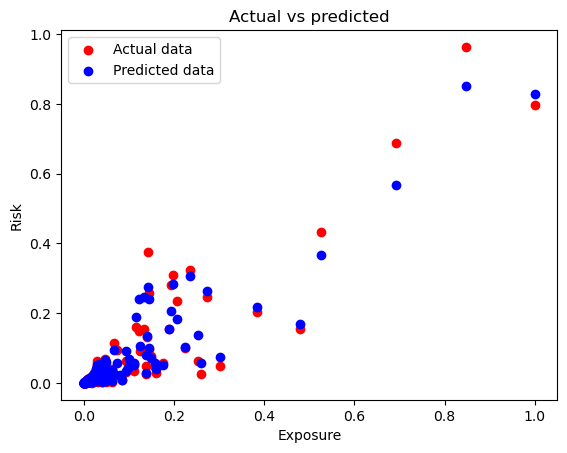

In [100]:
plt.scatter(X_test['Exposure'], y_test, label = 'Actual data', color = 'red')
plt.scatter(X_test['Exposure'], y_pred, label = 'Predicted data', color = 'blue')
plt.xlabel('Exposure')
plt.ylabel('Risk')
plt.title('Actual vs predicted')
plt.legend()
plt.show()

Feature Importance:
Exposure         0.790189
Hazard           0.179457
Vulnerability    0.030354
dtype: float64


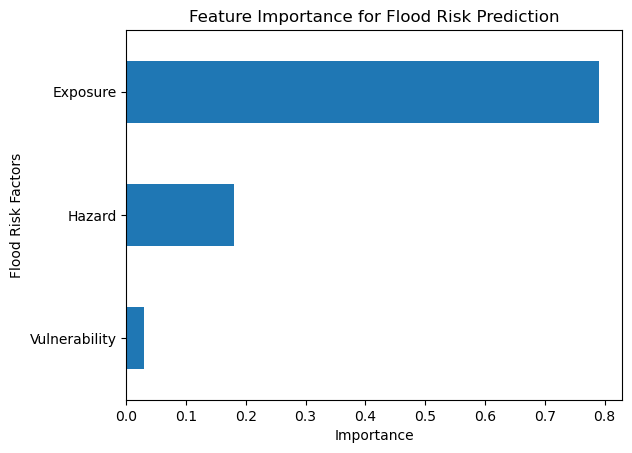

In [102]:
importance = pd.Series(
    model.feature_importances_,
    index=["Vulnerability", "Hazard", "Exposure"]
)

print("Feature Importance:")
print(importance.sort_values(ascending=False))

# Plot
importance.sort_values().plot(kind="barh")

plt.title("Feature Importance for Flood Risk Prediction")
plt.xlabel("Importance")
plt.ylabel("Flood Risk Factors")
plt.show()

In [104]:
def risk_level(risk):
    if risk < 0.30:
        return "Low"
    elif risk < 0.60:
        return "Medium"
    else:
        return "High"

data["Risk Level"] = data["Risk"].apply(risk_level)

print(data["Risk Level"].value_counts())

Risk Level
Low       710
Medium     22
High       10
Name: count, dtype: int64


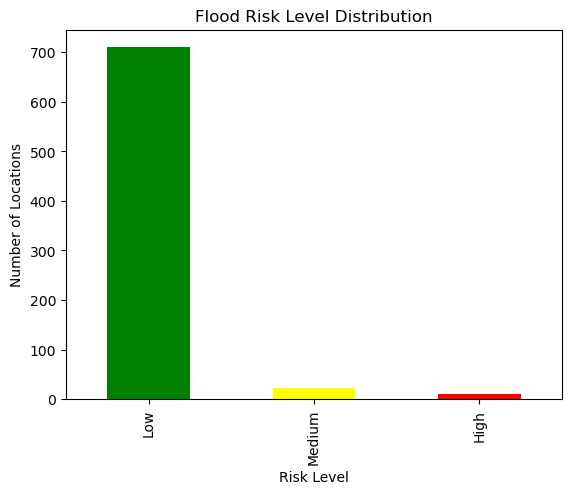

In [106]:
color = ["green","yellow","red"]
data["Risk Level"].value_counts().plot(kind="bar",color = color)

plt.title("Flood Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Locations")
plt.show()

In [108]:
risk_percentage = data["Risk Level"].value_counts(normalize=True) * 100

print(risk_percentage)

Risk Level
Low       95.687332
Medium     2.964960
High       1.347709
Name: proportion, dtype: float64


      ID  Vulnerability  Hazard  Exposure   Risk Risk Level
564  565          0.647    0.64     0.889  1.000       High
457  458          0.653    0.64     0.848  0.963       High
490  491          0.684    0.68     0.753  0.952       High
581  582          0.643    0.46     0.992  0.797       High
552  553          0.459    0.64     1.000  0.797       High
508  509          0.928    0.66     0.434  0.723       High
578  579          0.680    0.68     0.575  0.722       High
531  532          0.680    0.54     0.691  0.689       High
540  541          0.455    0.58     0.875  0.628       High
567  568          0.803    0.56     0.503  0.615       High


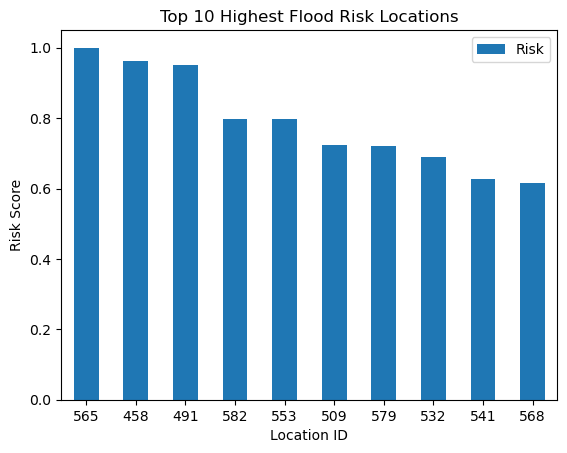

In [110]:
top_risk = data.sort_values(
    by="Risk",
    ascending=False
).head(10)

print(top_risk)
top_risk.plot(x="ID",y="Risk",kind="bar")

plt.title("Top 10 Highest Flood Risk Locations")
plt.xlabel("Location ID")
plt.ylabel("Risk Score")
plt.xticks(rotation=0)
plt.show()

In [112]:
model

RandomForestRegressor(random_state=42)

In [114]:
def predict_flood_risk(vulnerability, hazard, exposure):

    input_data = pd.DataFrame(
        [[vulnerability, hazard, exposure]],
        columns=["Vulnerability", "Hazard", "Exposure"]
    )

    prediction = model.predict(input_data)[0]

    if prediction < 0.1:
        level = "Low"
    elif prediction < 0.5:
        level = "Medium"
    else:
        level = "High"

    print("Predicted Flood Risk:", round(prediction, 3))
    print("Risk Level:", level)

    return prediction, level

predict_flood_risk(0.65, 0.64, 0.89)

Predicted Flood Risk: 0.923
Risk Level: High


(0.9232999999999998, 'High')

In [116]:
import pandas as pd


locations = pd.read_csv("Ind_adm2_Points.csv", encoding="latin1")

print(locations.columns)
print(locations.head())


Index(['ÿCountry', 'District', 'Ind_adm2_ID', 'point_order', 'State',
       'sub_polygon_id', 'Latitude', 'Longitude', 'Number of Records'],
      dtype='object')
  ÿCountry         District  Ind_adm2_ID  point_order                State  \
0    India  Andaman Islands            0          326  Andaman and Nicobar   
1    India  Andaman Islands            0          327  Andaman and Nicobar   
2    India  Andaman Islands            0          328  Andaman and Nicobar   
3    India  Andaman Islands            0          329  Andaman and Nicobar   
4    India  Andaman Islands            0          330  Andaman and Nicobar   

   sub_polygon_id  Latitude  Longitude  Number of Records  
0              28   11.5957    92.5322                  1  
1              28   11.5963    92.5325                  1  
2              28   11.5969    92.5327                  1  
3              28   11.5974    92.5329                  1  
4              28   11.5980    92.5331                  1  


In [118]:
district_locations = locations.groupby(
    ["State", "District"]
)[["Latitude", "Longitude"]].mean().reset_index()

print(district_locations.head())
print("Number of districts:", len(district_locations))

                 State         District   Latitude  Longitude
0  Andaman and Nicobar  Andaman Islands  12.382571  92.822911
1  Andaman and Nicobar  Nicobar Islands   7.835291  93.511601
2       Andhra Pradesh         Adilabad  19.284514  78.813212
3       Andhra Pradesh        Anantapur  14.312066  77.460158
4       Andhra Pradesh         Chittoor  13.331093  78.927639
Number of districts: 594


In [120]:
print(district_locations.shape)

(594, 4)


In [122]:
print(data.head())
print(data.columns)
print(data.shape)

   ID  Vulnerability  Hazard  Exposure   Risk Risk Level
0   1          0.534    0.08     0.011  0.001        Low
1   2          0.622    0.00     0.000  0.000        Low
2   3          0.421    0.10     0.000  0.000        Low
3   4          0.631    0.14     0.009  0.002        Low
4   5          0.580    0.12     0.031  0.006        Low
Index(['ID', 'Vulnerability', 'Hazard', 'Exposure', 'Risk', 'Risk Level'], dtype='object')
(742, 6)


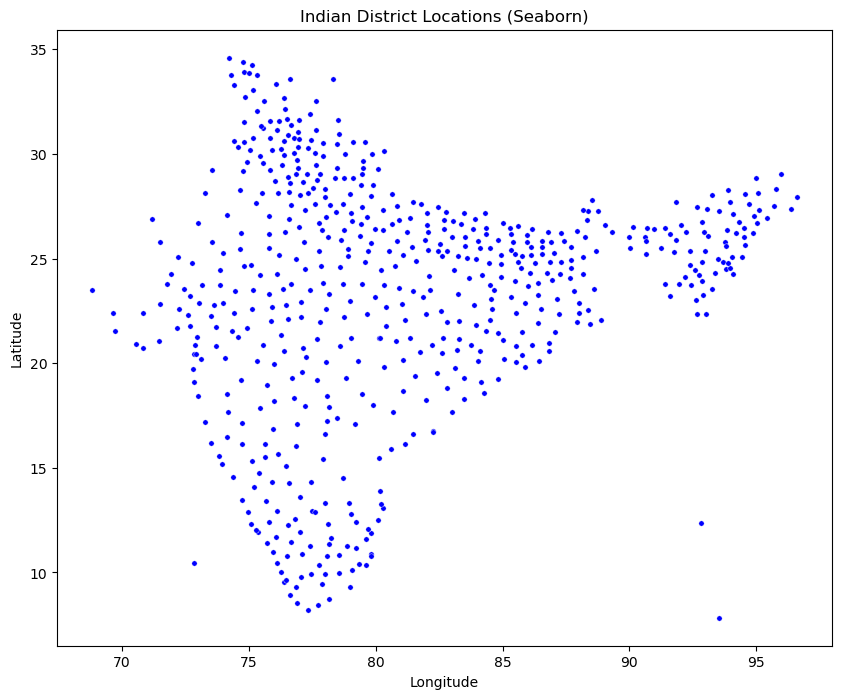

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(data=district_locations, x="Longitude", y="Latitude", s=15, color="blue")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Indian District Locations (Seaborn)")
plt.show()


In [126]:
# Keep one geographical point for each district
district_locations = locations.groupby(["District", "State"],as_index=False)[["Latitude", "Longitude"]].mean()

print(district_locations.shape)
print(district_locations.head())

(594, 4)
     District           State   Latitude  Longitude
0    Adilabad  Andhra Pradesh  19.284514  78.813212
1        Agra   Uttar Pradesh  26.995130  78.052783
2   Ahmadabad         Gujarat  22.605426  72.238981
3  Ahmednagar     Maharashtra  19.217599  74.692203
4      Aizawl         Mizoram  23.907813  92.853595


In [128]:
risk_data = data.iloc[:594].copy()

print(risk_data.shape)

(594, 6)


In [130]:
map_data = pd.concat([district_locations.reset_index(drop=True), risk_data[["Risk", "Risk Level"]].reset_index(drop=True)],axis=1)
print(map_data.head())

     District           State   Latitude  Longitude   Risk Risk Level
0    Adilabad  Andhra Pradesh  19.284514  78.813212  0.001        Low
1        Agra   Uttar Pradesh  26.995130  78.052783  0.000        Low
2   Ahmadabad         Gujarat  22.605426  72.238981  0.000        Low
3  Ahmednagar     Maharashtra  19.217599  74.692203  0.002        Low
4      Aizawl         Mizoram  23.907813  92.853595  0.006        Low


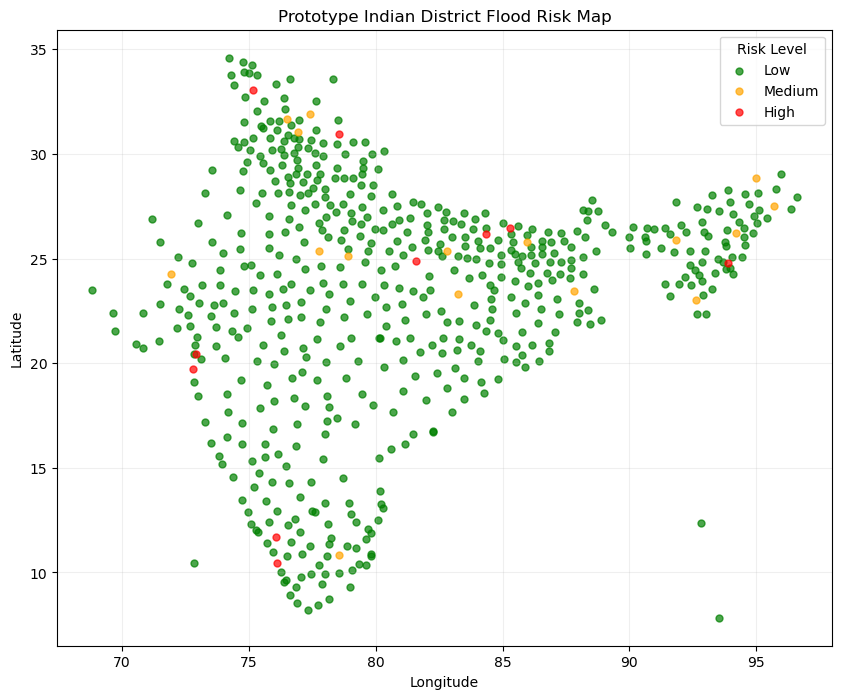

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

colors = {"Low": "green","Medium": "orange","High": "red"}

for level, color in colors.items():

    subset = map_data[map_data["Risk Level"] == level]

    plt.scatter( subset["Longitude"],subset["Latitude"], c=color,label=level,s=25,alpha=0.7)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Prototype Indian District Flood Risk Map")

plt.legend(title="Risk Level")
plt.grid(alpha=0.2)

plt.show()

In [134]:
import time
import random
import pandas as pd

for i in range(10):

    rainfall = random.uniform(50, 300)
    water_level = random.uniform(1, 10)
    discharge = random.uniform(500, 5000)
    soil_moisture = random.uniform(20, 100)
    population = random.uniform(1000, 10000)

    # Hazard
    hazard = (
        0.4 * (rainfall / 300) +
        0.3 * (water_level / 10) +
        0.3 * (discharge / 5000)
    )

    hazard = min(hazard, 1)

    # Exposure
    exposure = min(population / 10000, 1)

    # Vulnerability
    vulnerability = min(soil_moisture / 100, 1)

    # Model input
    live_input = pd.DataFrame({
        "Vulnerability": [vulnerability],
        "Hazard": [hazard],
        "Exposure": [exposure]
    })

    # Prediction
    risk = model.predict(live_input)[0]

    # Risk level
    if risk < 0.1:
        level = "Low"
    elif risk < 0.5:
        level = "Medium"
    else:
        level = "High"

    print("\n==============================")
    print("Sensor Reading:", i + 1)
    print("==============================")

    print("Rainfall:", round(rainfall, 2), "mm")
    print("Water Level:", round(water_level, 2), "m")
    print("River Discharge:", round(discharge, 2), "m3/s")
    print("Soil Moisture:", round(soil_moisture, 2), "%")

    print("\nHazard:", round(hazard, 3))
    print("Exposure:", round(exposure, 3))
    print("Vulnerability:", round(vulnerability, 3))

    print("\nPredicted Risk:", round(risk, 3))
    print("Risk Level:", level)

    if level == "High":
        print("🚨 FLOOD ALERT!")

    elif level == "Medium":
        print("⚠️ FLOOD WARNING")

    else:
        print("✓ NORMAL")

    time.sleep(2)


Sensor Reading: 1
Rainfall: 209.73 mm
Water Level: 4.0 m
River Discharge: 4898.45 m3/s
Soil Moisture: 42.89 %

Hazard: 0.693
Exposure: 0.79
Vulnerability: 0.429

Predicted Risk: 0.784
Risk Level: High
🚨 FLOOD ALERT!

Sensor Reading: 2
Rainfall: 165.09 mm
Water Level: 2.26 m
River Discharge: 4406.08 m3/s
Soil Moisture: 89.62 %

Hazard: 0.552
Exposure: 0.52
Vulnerability: 0.896

Predicted Risk: 0.566
Risk Level: High
🚨 FLOOD ALERT!

Sensor Reading: 3
Rainfall: 154.89 mm
Water Level: 3.46 m
River Discharge: 3063.28 m3/s
Soil Moisture: 24.36 %

Hazard: 0.494
Exposure: 0.413
Vulnerability: 0.244

Predicted Risk: 0.322
Risk Level: Medium
⚠️ FLOOD WARNING

Sensor Reading: 4
Rainfall: 108.78 mm
Water Level: 8.42 m
River Discharge: 850.17 m3/s
Soil Moisture: 95.09 %

Hazard: 0.449
Exposure: 0.654
Vulnerability: 0.951

Predicted Risk: 0.436
Risk Level: Medium
⚠️ FLOOD WARNING

Sensor Reading: 5
Rainfall: 268.91 mm
Water Level: 1.38 m
River Discharge: 597.7 m3/s
Soil Moisture: 87.41 %

Hazard: 0